In [1]:
import tensorflow as tf
import numpy as np

In [2]:
# Training parameters.
training_steps = 100
batch_size = 64
latent_dim = 64

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [4]:
# Convert to float32.
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Normalize images value from [0, 255] to [0, 1].
x_train, x_test = x_train / 255., x_test / 255.

# Reshape for input images with a single channel
x_train, x_test = np.expand_dims(x_train, axis=-1), np.expand_dims(x_test, axis=-1)

In [83]:
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape) 
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape) 

x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

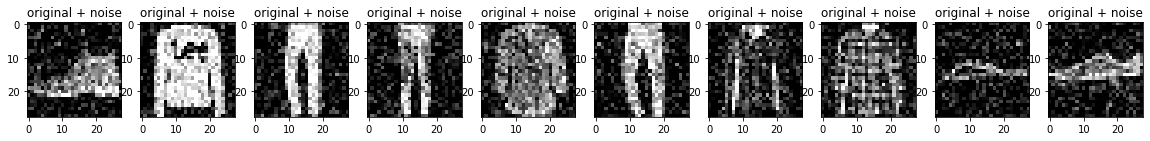

In [85]:
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(20, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.title("original + noise")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
plt.show()

In [82]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D, Flatten, Dense, Reshape

# define encoder layers
conv1 = Conv2D(6, kernel_size=(5, 5), strides=(1, 1), activation='relu', 
            input_shape=(28,28,1), padding="same")
maxpool1 = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
conv2 = Conv2D(16, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding='valid')
maxpool2 = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
flat = Flatten()
dense = Dense(latent_dim)

# define decoder layers
dense_T = Dense(400, activation='relu')
reshape = Reshape((5, 5, 16))
upsample1 = UpSampling2D(size=(2, 2))
conv1_T = Conv2DTranspose(16, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding='valid')
upsample2 = UpSampling2D(size=(2, 2))
conv2_T = Conv2DTranspose(6, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding='same')
output_T = Conv2DTranspose(1, kernel_size=(3, 3), padding='same')

# define model: encoder
input_img = tf.keras.Input(shape=(28, 28, 1))
_conv1 = conv1(input_img)
_maxpool1 = maxpool1(_conv1)
_conv2 = conv2(_maxpool1)
_maxpool2 = maxpool2(_conv2)
_flat = flat(_maxpool2)
_dense = dense(_flat)

# shapes of tensors in encoder
print(_conv1.shape)
print(_maxpool1.shape)
print(_conv2.shape)
print(_maxpool2.shape)
print(_flat.shape)
print(_dense.shape)

# define model: decoder
_dense_T = dense_T(_dense)
_reshape = reshape(_dense_T)
_upsample1 = upsample1(_reshape)
_conv1_T = conv1_T(_upsample1)
_upsample2 = upsample1(_conv1_T)
_conv2_T = conv2_T(_upsample2)
output_img = output_T(_conv2_T)

# shapes of tensors in decoder
print(_dense_T.shape)
print(_reshape.shape)
print(_upsample1.shape)
print(_conv1_T.shape)
print(_upsample2.shape)
print(_conv2_T.shape)
print(output_img.shape)

(None, 28, 28, 6)
(None, 14, 14, 6)
(None, 10, 10, 16)
(None, 5, 5, 16)
(None, 400)
(None, 64)
(None, 400)
(None, 5, 5, 16)
(None, 10, 10, 16)
(None, 14, 14, 16)
(None, 28, 28, 16)
(None, 28, 28, 6)
(None, 28, 28, 1)


In [96]:
from tensorflow.keras import losses

# compile the model
autoencoder = tf.keras.Model(input_img, output_img)
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError(), metrics=["mse"])

# fit the model
autoencoder.fit(x_train_noisy, x_train, 
          epochs=training_steps, batch_size=batch_size, 
          validation_data=(x_test_noisy, x_test), verbose=1)

Epoch 1/100
938/938 [==============================] - 5s 6ms/step - loss: 0.0088 - mse: 0.0088 - val_loss: 0.0089 - val_mse: 0.0089
Epoch 2/100
938/938 [==============================] - 5s 5ms/step - loss: 0.0088 - mse: 0.0088 - val_loss: 0.0090 - val_mse: 0.0090
Epoch 3/100
938/938 [==============================] - 5s 5ms/step - loss: 0.0088 - mse: 0.0088 - val_loss: 0.0091 - val_mse: 0.0091
Epoch 4/100
938/938 [==============================] - 5s 5ms/step - loss: 0.0088 - mse: 0.0088 - val_loss: 0.0089 - val_mse: 0.0089
Epoch 5/100
938/938 [==============================] - 5s 5ms/step - loss: 0.0088 - mse: 0.0088 - val_loss: 0.0090 - val_mse: 0.0090
Epoch 6/100
938/938 [==============================] - 5s 5ms/step - loss: 0.0088 - mse: 0.0088 - val_loss: 0.0089 - val_mse: 0.0089
Epoch 7/100
938/938 [==============================] - 5s 5ms/step - loss: 0.0088 - mse: 0.0088 - val_loss: 0.0089 - val_mse: 0.0089
Epoch 8/100
938/938 [==============================] - 5s 5ms/step - 

In [94]:
decoded_imgs = autoencoder.predict(x_test)

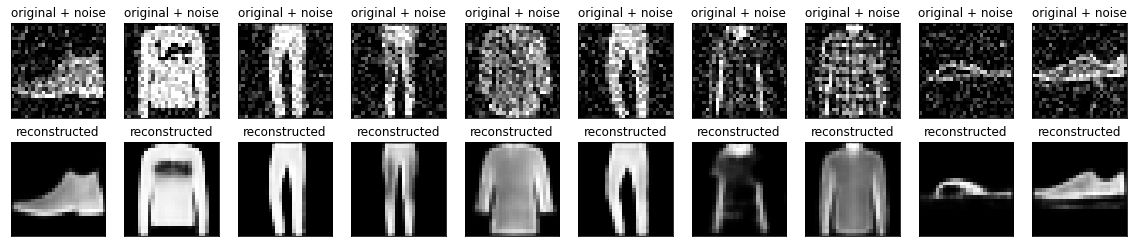

In [95]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):

    # display original + noise
    ax = plt.subplot(2, n, i + 1)
    plt.title("original + noise")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    bx = plt.subplot(2, n, i + n + 1)
    plt.title("reconstructed")
    plt.imshow(tf.squeeze(decoded_imgs[i]))
    plt.gray()
    bx.get_xaxis().set_visible(False)
    bx.get_yaxis().set_visible(False)
plt.show()